# Gisement de flexibilité — simulation contrefactuelle

La consigne de thermostat est une **entrée** du réseau de `06_timeseries/timeseries_net`. On peut donc la modifier et relire la courbe de charge : c'est une expérience contrefactuelle.

```
consignes réelles    -> f(t)  -> modèle -> courbe de référence
consignes modifiées  -> f'(t) -> modèle -> courbe scénario

        ΔP(t) = référence − scénario     = puissance effacée à l'heure t
```

**Ce qui rend la démarche crédible** : une partie des bâtiments du parc ont déjà un réduit de nuit dans leurs consignes. Le réseau a donc appris sur des variations de consigne intra-journalières réelles et leurs conséquences — ce ne sont pas des extrapolations pures.

**Limite assumée** : le modèle ne prédit pas la température intérieure, donc le confort n'est pas vérifié. C'est pourquoi les scénarios bornent le décalage de consigne à ±2 °C, du même ordre que les offsets que ResStock applique déjà lui-même.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from functools import lru_cache
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA   = Path().resolve().parent.parent / 'data' / 'processed'
TS_BASE = ('https://oedi-data-lake.s3.amazonaws.com/nrel-pds-building-stock/'
           'end-use-load-profiles-for-us-building-stock/2025/resstock_amy2018_release_1/'
           'timeseries_individual_buildings/by_state/upgrade=0')

SEQ_LEN = 168
NOMS    = ['total', 'chauffage', 'clim', 'eau_chaude']

## 1. Définitions reprises de `timeseries_net`

`load_building` et `LoadNet` sont **recopiées à l'identique** depuis `06_timeseries/timeseries_net.ipynb`. Si tu modifies `f(t)` là-bas, il faut les remettre à jour ici — le test d'identité de la section 3 le détectera.

**Tête multiplicative** (03/08) : le réseau ne sort pas des kWh mais une *forme* sans dimension, remise à l'échelle par le niveau annuel LightGBM. `forward` prend donc **trois** arguments — `(f(t), s, niveau)`. Un appel à deux arguments ne lève pas seulement une erreur : il produirait une courbe sans échelle, donc un gisement faux d'un facteur bâtiment.

`load_building` est mise en cache : chaque bâtiment est lu **cinq** fois dans la suite du notebook (trois scénarios + test négatif + profil moyen), pour un fichier de 35 040 lignes rééchantillonné à chaque appel.

In [2]:
WEA = ['out.outdoor_air_drybulb_temp..c', 'out.outdoor_air_relative_humidity..percentage',
       'out.weather.wind_speed..meter_per_second',
       'out.weather.direct_normal_solar_radiation..watt_per_m2',
       'out.weather.diffuse_solar_radiation..watt_per_m2']
SCHED = ['out.schedules.' + s for s in [
    'occupants', 'vacancy', 'lighting_interior', 'lighting_garage', 'plug_loads_other',
    'plug_loads_tv', 'clothes_dryer', 'clothes_washer', 'dishwasher', 'cooking_range',
    'ceiling_fan', 'hot_water_fixtures', 'hot_water_clothes_washer', 'hot_water_dishwasher',
    'no_space_cooling', 'no_space_heating']]
SETP = ['out.schedules.heating_setpoint..c', 'out.schedules.cooling_setpoint..c']
TGT  = ['out.electricity.' + t + '.energy_consumption..kwh' for t in
        ['total', 'heating', 'cooling', 'hot_water']]
C_HEAT, C_COOL = SETP
C_TEXT = WEA[0]

@lru_cache(maxsize=None)
def load_building(bldg_id, state):
    """Identique à timeseries_net : f(t) horaire et cibles horaires.

    EN CACHE : la suite du notebook redemande chaque bâtiment cinq fois (trois scénarios,
    le test négatif, le profil moyen) et chaque appel relit 35 040 lignes puis rééchantillonne.
    Le DataFrame renvoyé est PARTAGÉ entre appels : ne jamais le modifier en place —
    `predire` en prend une copie avant de toucher aux consignes.
    """
    path = DATA / f'{bldg_id}-0.parquet'
    ts = pd.read_parquet(path if path.exists() else f'{TS_BASE}/state={state}/{bldg_id}-0.parquet')
    ts['timestamp'] = pd.to_datetime(ts['timestamp'])
    brut = ts.set_index('timestamp').reindex(columns=WEA + SCHED + SETP + TGT)
    h = brut[WEA + SCHED + SETP].resample('1h').mean().iloc[:8760]   # grandeurs instantanées
    y = brut[TGT].resample('1h').sum().iloc[:8760]                   # énergies -> somme
    h[SCHED] = h[SCHED].fillna(0.0)
    if h[SETP].isna().any().any():
        raise ValueError(f'bâtiment {bldg_id} : consignes absentes.')
    i = h.index
    cal = pd.DataFrame({
        'h_sin': np.sin(2*np.pi*i.hour/24),      'h_cos': np.cos(2*np.pi*i.hour/24),
        'd_sin': np.sin(2*np.pi*i.dayofweek/7),  'd_cos': np.cos(2*np.pi*i.dayofweek/7),
        'm_sin': np.sin(2*np.pi*(i.month-1)/12), 'm_cos': np.cos(2*np.pi*(i.month-1)/12),
    }, index=i)
    t_ext = h[C_TEXT]
    ecart = pd.DataFrame({
        'ecart_chauffage': (h[C_HEAT] - t_ext).clip(lower=0),
        'ecart_clim':      (t_ext - h[C_COOL]).clip(lower=0),
    }, index=i)
    return pd.concat([h[WEA + SCHED + SETP], cal, ecart], axis=1), y


class LoadNet(nn.Module):
    """Identique à timeseries_net : GRU bidirectionnel + statique, TÊTE MULTIPLICATIVE.

    `forward` prend TROIS arguments. Le réseau produit une forme sans dimension (~1) et c'est
    `niveau` — la puissance moyenne annuelle prédite par LightGBM, usage par usage — qui porte
    l'échelle du bâtiment. Voir la docstring de LoadNet dans timeseries_net pour le pourquoi.
    """
    def __init__(self, n_time, n_static, hidden=128, n_out=4):
        super().__init__()
        self.gru  = nn.GRU(n_time, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2 + n_static, hidden), nn.ReLU(),
            nn.Linear(hidden, n_out),
            nn.Softplus(),
        )

    def forward(self, x_time, static, niveau):
        h, _ = self.gru(x_time)
        s = static.unsqueeze(1).expand(-1, h.size(1), -1)
        forme = self.head(torch.cat([h, s], dim=-1))     # (B, T, n_out), sans dimension
        return forme * niveau.unsqueeze(1)               # niveau attendu dans l'échelle de ys

## 2. Charger le modèle entraîné

Produit par la dernière cellule de `06_timeseries/timeseries_net`. Le checkpoint contient le modèle, les constantes de normalisation **et** tout ce qui est propre à chaque bâtiment :

| clé | contenu | pourquoi c'est indispensable |
|---|---|---|
| `xm, xs, sm, ss, ys` | normalisation de `f(t)`, de `s`, échelle des cibles | présenter au réseau une entrée cohérente, relire des kWh |
| `statique` | le vecteur `s` de 54 colonnes, par bâtiment | 4 LightGBM + 48 features + **2 présence d'équipement** — les deux dernières viennent de `metadata_clean`, on ne peut pas les refabriquer depuis `static_preds` seul |
| `niveau` | puissance moyenne annuelle LightGBM (kWh/h), par bâtiment et usage | facteur d'échelle de la tête multiplicative |
| `gate` | masque de présence d'équipement | 16 % du parc n'a pas d'ECS électrique, 5 % pas de clim : sortie forcée à zéro, `Softplus` ne l'atteint jamais seule |

On les relit tels quels plutôt que de refaire les jointures : c'est exactement ce qui avait désynchronisé ce notebook (il reconstruisait un `s` à 52 colonnes).

In [3]:
ck = torch.load(DATA / 'loadnet.pt', weights_only=False)
assert ck['archi'] == 'gru_bidirectionnel_multiplicatif', \
    f"checkpoint « {ck['archi']} » : ce notebook suppose la tête multiplicative (forward à 3 arguments)."
xm, xs, sm, ss, ys = ck['xm'], ck['xs'], ck['sm'], ck['ss'], ck['ys']
COLONNES, BUILDINGS = ck['colonnes'], ck['buildings']
VAL_B = sorted(int(b) for b in ck['val_b'])

model = LoadNet(ck['n_time'], ck['n_static'], ck['hidden'], ck['n_out']).to(device)
model.load_state_dict(ck['state_dict'])
model.eval()

# Tout ce qui dépend du bâtiment est relu du checkpoint, jamais reconstruit : c'est la seule
# garantie que le réseau voit exactement les mêmes entrées qu'à l'entraînement.
# Les clés sont des int Python ; VAL_B et ETAT le sont aussi pour que l'indexation marche.
STATIQUE = {int(b): np.array(v, dtype='float32') for b, v in ck['statique'].items()}
NIVEAU   = {int(b): np.array(v, dtype='float32') for b, v in ck['niveau'].items()}   # kWh/h
GATE     = {int(b): np.array(v, dtype='float32') for b, v in ck['gate'].items()}
ETAT     = {int(b): st for b, st in BUILDINGS}

# features physiques : uniquement pour l'analyse de cohérence de la section 6
feat = pd.read_parquet(DATA / 'X_47features.parquet')
feat = feat.assign(tau=feat['C'] / (feat['UA'] + feat['H_ve']) / 3.6)   # constante de temps (h)

n_sans_clim = sum(1 for b in VAL_B if GATE[b][2] == 0)
n_sans_ecs  = sum(1 for b in VAL_B if GATE[b][3] == 0)
print(f"f(t) = {ck['n_time']} entrées | s = {ck['n_static']} | {len(BUILDINGS)} bâtiments")
print(f'{len(VAL_B)} bâtiments de validation (jamais vus à l\'entraînement)')
print(f'  dont {n_sans_clim} sans clim et {n_sans_ecs} sans ECS électrique (sortie gatée à zéro)')

f(t) = 31 entrées | s = 54 | 503 bâtiments
101 bâtiments de validation (jamais vus à l'entraînement)
  dont 7 sans clim et 19 sans ECS électrique (sortie gatée à zéro)


## 3. La fonction contrefactuelle

**Le point critique** : `f(t)` contient les consignes **et** les écarts `max(0, consigne − T_ext)`. Décaler la consigne sans recalculer les écarts présenterait au réseau une entrée physiquement incohérente. Les deux doivent bouger ensemble.

In [4]:
to_t = lambda a: torch.tensor(a, dtype=torch.float32)

def predire(f, bldg_id, delta_ch=0.0, delta_cl=0.0, heures=None, mois=None):
    """Courbe horaire prédite (kWh) en décalant les consignes sur les heures visées.

    f        : DataFrame f(t) NON normalisé, sortie de load_building (jamais modifié en place)
    bldg_id  : identifiant du bâtiment — sert à retrouver s, niveau et gate dans le checkpoint
    delta_ch : décalage de la consigne de chauffage (°C, négatif = effacement)
    delta_cl : décalage de la consigne de clim     (°C, positif = effacement)
    heures   : heures de la journée concernées, ex. range(18, 21) ; None = toutes
    mois     : mois concernés, ex. [12, 1, 2] ; None = tous

    Retourne (kwh, index) alignés : kwh de forme (n_heures, 4).
    """
    g = f.copy()
    m = np.ones(len(g), dtype=bool)
    if heures is not None:
        m &= g.index.hour.isin(list(heures))
    if mois is not None:
        m &= g.index.month.isin(list(mois))

    g.loc[m, C_HEAT] += delta_ch
    g.loc[m, C_COOL] += delta_cl

    # RECALCUL OBLIGATOIRE : les écarts dépendent des consignes
    t_ext = g[C_TEXT]
    g['ecart_chauffage'] = (g[C_HEAT] - t_ext).clip(lower=0)
    g['ecart_clim']      = (t_ext - g[C_COOL]).clip(lower=0)

    # le réseau lit des positions, pas des noms : un f(t) réordonné passerait sans erreur
    assert list(g.columns) == COLONNES, 'f(t) désaligné du checkpoint — recopier load_building'

    n = len(g) // SEQ_LEN
    X = g.values[:n*SEQ_LEN].reshape(n, SEQ_LEN, -1)
    Xn   = (X - xm) / xs
    Sn   = np.tile((STATIQUE[bldg_id] - sm) / ss, (n, 1))
    NIVn = np.tile(NIVEAU[bldg_id] / ys.reshape(1, -1), (n, 1))   # niveau dans l'échelle de ys
    with torch.no_grad():
        p = model(to_t(Xn).to(device), to_t(Sn).to(device), to_t(NIVn).to(device)).cpu().numpy()
    p = p * GATE[bldg_id] * ys        # masque d'équipement, puis dé-normalisation en kWh
    return p.reshape(-1, p.shape[-1]), g.index[:n*SEQ_LEN]

### Test d'identité

Avec un décalage nul, `predire` doit redonner **exactement** la prédiction de référence. C'est ce qui prouve que la machinerie contrefactuelle ne casse rien.

In [5]:
b_test = VAL_B[0]
f_test, y_test = load_building(b_test, ETAT[b_test])

ref, idx = predire(f_test, b_test)
nul, _   = predire(f_test, b_test, delta_ch=0.0, delta_cl=0.0, heures=range(18, 21))
ecart_max = np.abs(ref - nul).max()

print(f'bâtiment {b_test} | {len(idx)} heures prédites')
print(f'écart maximal entre référence et delta=0 : {ecart_max:.2e}')
assert ecart_max < 1e-9, 'la fonction contrefactuelle modifie la prédiction alors que delta=0'
print('test d\'identité OK')

# qualité de la référence sur ce bâtiment, pour situer
from sklearn.metrics import r2_score
yv = y_test.values[:len(idx)]
for i, n in enumerate(NOMS):
    print(f'  {n:11} R² = {r2_score(yv[:, i], ref[:, i]):6.3f}   '
          f'annuel réel {yv[:, i].sum():7.0f} kWh / prédit {ref[:, i].sum():7.0f}')

bâtiment 21453 | 8736 heures prédites
écart maximal entre référence et delta=0 : 0.00e+00
test d'identité OK


  total       R² =  0.932   annuel réel   21430 kWh / prédit   21304
  chauffage   R² =  0.952   annuel réel    5700 kWh / prédit    5744
  clim        R² =  0.951   annuel réel    5755 kWh / prédit    5489
  eau_chaude  R² =  0.693   annuel réel    1241 kWh / prédit    1098


## 4. Scénarios d'effacement

On borne **l'action** (le décalage de consigne), pas l'effet — faute de contrainte de confort. Les magnitudes retenues sont du même ordre que les offsets présents dans ResStock.

| scénario | saison | heures | décalage |
|---|---|---|---|
| effacement soir | hiver | 18–21 h | chauffage −2 °C |
| effacement matin | hiver | 7–10 h | chauffage −2 °C |
| effacement pointe été | été | 15–19 h | clim +2 °C |

In [6]:
HIVER, ETE = [12, 1, 2], [6, 7, 8]

SCENARIOS = {
    'soir hiver  (chauffage −2 °C, 18–21 h)': dict(delta_ch=-2.0, heures=range(18, 21), mois=HIVER, cible=1),
    'matin hiver (chauffage −2 °C, 7–10 h)' : dict(delta_ch=-2.0, heures=range(7, 10),  mois=HIVER, cible=1),
    'pointe été  (clim +2 °C, 15–19 h)'     : dict(delta_cl=+2.0, heures=range(15, 19), mois=ETE,   cible=2),
}

def fenetre_rebond(ev, apres):
    """Les `apres` heures qui suivent chaque bloc d'évènement, en TEMPS ABSOLU.

    Bug corrigé : la version précédente prenait `range(fin, fin + apres)` comme heures de la
    journée. Pour un évènement finissant à 21 h et `apres = 6`, ça donnait range(21, 27) —
    les heures 24 à 26 n'existent pas, donc seules 3 heures de rebond sur 6 étaient comptées
    et le report était sous-estimé de moitié. Décaler les positions plutôt que filtrer sur
    l'heure traverse naturellement minuit, et donc aussi les fins de mois.
    """
    fins = np.flatnonzero(ev & ~np.r_[ev[1:], False])      # dernière heure de chaque bloc
    rb = np.zeros_like(ev)
    for k in range(1, apres + 1):
        q = fins + k
        rb[q[q < len(rb)]] = True
    return rb & ~ev                                        # un rebond n'est pas un évènement

def indicateurs(bldg_id, scen, apres=6):
    """Effacement et rebond d'un bâtiment pour un scénario, en kWh."""
    p = {k: v for k, v in scen.items() if k != 'cible'}
    cible = scen['cible']
    f, _ = load_building(bldg_id, ETAT[bldg_id])
    ref, idx = predire(f, bldg_id)
    sc,  _   = predire(f, bldg_id, **p)
    dP = ref - sc                                    # >0 = puissance effacée

    ev = idx.hour.isin(list(p['heures'])) & idx.month.isin(list(p['mois']))
    rb = fenetre_rebond(ev, apres)

    return {
        'bldg_id'      : bldg_id,
        'pointe_kW'    : dP[ev, cible].max(),
        'efface_kWh'   : dP[ev, cible].sum(),
        'rebond_kWh'   : -dP[rb, cible].sum(),        # >0 = énergie reportée après
        'efface_total' : dP[ev, 0].sum(),
        'n_heures_ev'  : int(ev.sum()),
    }

## 5. Balayage du parc

On n'évalue que sur les bâtiments de **validation** : ceux que le réseau n'a jamais vus. Un gisement calculé sur des bâtiments d'entraînement serait optimiste.

In [7]:
resultats = {}
for nom, scen in SCENARIOS.items():
    lignes = [indicateurs(b, scen) for b in VAL_B]
    resultats[nom] = pd.DataFrame(lignes).set_index('bldg_id')
    print(f'{nom} : {len(lignes)} bâtiments')

recap = pd.DataFrame({
    nom: {
        'pointe effacée médiane (kW)'  : d['pointe_kW'].median(),
        'énergie effacée médiane (kWh)': d['efface_kWh'].median(),
        'rebond médian (kWh)'          : d['rebond_kWh'].median(),
        'taux de report (%)'           : 100 * d['rebond_kWh'].sum() / max(d['efface_kWh'].sum(), 1e-9),
    } for nom, d in resultats.items()
}).T.round(2)
print()
print(recap.to_string())

soir hiver  (chauffage −2 °C, 18–21 h) : 101 bâtiments


matin hiver (chauffage −2 °C, 7–10 h) : 101 bâtiments


pointe été  (clim +2 °C, 15–19 h) : 101 bâtiments

                                        pointe effacée médiane (kW)  énergie effacée médiane (kWh)  rebond médian (kWh)  taux de report (%)
soir hiver  (chauffage −2 °C, 18–21 h)                         0.67                      77.019997            -3.600000           -3.460000
matin hiver (chauffage −2 °C, 7–10 h)                          0.74                     117.260002            42.400002           34.500000
pointe été  (clim +2 °C, 15–19 h)                              0.54                     134.070007            30.440001           22.030001


## 6. Validation

**Test négatif** : décaler la consigne de chauffage en plein été ne doit rien effacer. Si le modèle prédit un effet, il a appris une corrélation parasite et le gisement n'est pas fiable.

**Cohérence physique** : l'effacement doit croître avec `UA` (mal isolé → se refroidit vite → efface plus), et le rebond s'étaler avec `tau` (bâtiment lourd → report plus lent).

In [8]:
# --- test négatif : chauffage en été ---
scen_abs = dict(delta_ch=-2.0, heures=range(18, 21), mois=ETE, cible=1)
d_abs = pd.DataFrame([indicateurs(b, scen_abs) for b in VAL_B]).set_index('bldg_id')
d_ref = resultats['soir hiver  (chauffage −2 °C, 18–21 h)']
print('TEST NÉGATIF — consigne de chauffage décalée en été')
print(f"  énergie effacée médiane : {d_abs['efface_kWh'].median():.4f} kWh")
print(f"  (en hiver, même scénario : {d_ref['efface_kWh'].median():.4f} kWh)")
print(f"  rapport été/hiver des sommes parc : "
      f"{100 * d_abs['efface_kWh'].sum() / max(d_ref['efface_kWh'].sum(), 1e-9):.1f} %")
print('  -> doit être proche de 0, sinon corrélation parasite')

# --- cohérence physique ---
print()
print('COHÉRENCE PHYSIQUE — corrélation de Spearman avec les agrégats d\'enveloppe')
print('  attendu : effacement croissant avec UA (mal isolé -> se refroidit vite)')
phys = feat.loc[d_ref.index, ['UA', 'C', 'tau', 'A_solaire']]
for col in ['efface_kWh', 'rebond_kWh']:
    c = phys.corrwith(d_ref[col], method='spearman').round(3)
    print(f'  {col:12} ' + '  '.join(f'{k}={v:+.2f}' for k, v in c.items()))

TEST NÉGATIF — consigne de chauffage décalée en été
  énergie effacée médiane : 0.0580 kWh
  (en hiver, même scénario : 77.0189 kWh)
  rapport été/hiver des sommes parc : 0.3 %
  -> doit être proche de 0, sinon corrélation parasite

COHÉRENCE PHYSIQUE — corrélation de Spearman avec les agrégats d'enveloppe
  attendu : effacement croissant avec UA (mal isolé -> se refroidit vite)
  efface_kWh   UA=+0.11  C=+0.10  tau=+0.03  A_solaire=-0.02
  rebond_kWh   UA=-0.03  C=-0.12  tau=-0.07  A_solaire=-0.20


## 7. Profil moyen d'effacement

Le graphe du rapport : creux pendant l'évènement, bosse de rebond après.

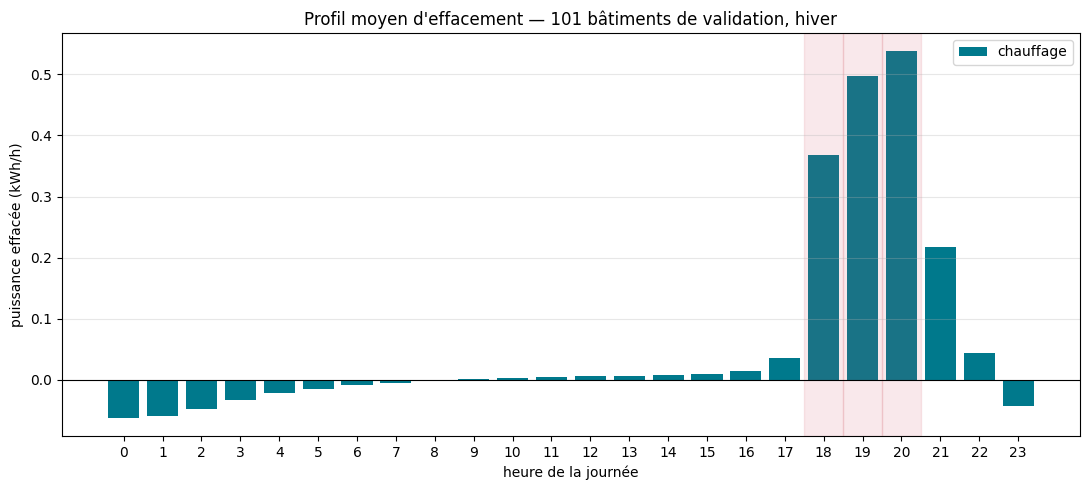

zone rouge = évènement | barres positives = effacement | négatives = rebond


In [9]:
scen = SCENARIOS['soir hiver  (chauffage −2 °C, 18–21 h)']
p = {k: v for k, v in scen.items() if k != 'cible'}

profils = []
for b in VAL_B:
    f, _ = load_building(b, ETAT[b])
    ref, idx = predire(f, b)
    sc, _    = predire(f, b, **p)
    dP = pd.DataFrame(ref - sc, index=idx, columns=NOMS)
    saison = idx.month.isin(p['mois'])
    profils.append(dP[saison].groupby(idx[saison].hour).mean())

moyen = sum(profils) / len(profils)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(moyen.index, moyen['chauffage'], color='#00798c', label='chauffage')
ax.axhline(0, color='black', lw=0.8)
for h in p['heures']:
    ax.axvspan(h - 0.5, h + 0.5, color='#d1495b', alpha=0.12)
ax.set(title=f"Profil moyen d'effacement — {len(profils)} bâtiments de validation, hiver",
       xlabel='heure de la journée', ylabel='puissance effacée (kWh/h)')
ax.set_xticks(range(0, 24))
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()

print('zone rouge = évènement | barres positives = effacement | négatives = rebond')